In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Set date range
end_date = datetime.now()
start_date = end_date - timedelta(days=365*10)

# Define portfolio
portfolio = ['AAPL', 'TSLA', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'AVGO', 'BRK-B', 'WMT']

# Create an empty DataFrame to store returns
returns_df = pd.DataFrame()

# Download data and calculate returns for each ticker
for ticker in portfolio:
    # Download data
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    # Calculate returns and add to the DataFrame
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna() 
# Print the returns DataFrame
print(returns_df)

# Creare un nuovo DataFrame con le statistiche
statistics_df = pd.DataFrame({
    'Expected Return': returns_df.mean(),          # Media dei rendimenti
    'Variance': returns_df.var(),                  # Varianza
    'Standard Deviation': returns_df.std()         # Deviazione standard
})

# Rinomina l'indice
statistics_df.index.name = 'Ticker'

# Arrotonda i valori a 4 decimali per una migliore leggibilità
statistics_df = statistics_df.round(4)

# Stampa il DataFrame delle statistiche
print("\nPortfolio Statistics:")
print(statistics_df)

# Calcola la matrice di correlazione
correlation_matrix = returns_df.corr()

# Arrotonda i valori
correlation_matrix = correlation_matrix.round(4)

# Stampa la matrice di correlazione
print("\nCorrelation Matrix:")
print(correlation_matrix)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                AAPL      TSLA      MSFT      NVDA      AMZN     GOOGL  \
Date                                                                     
2015-08-01 -0.070404 -0.064212 -0.068094  0.126817 -0.043383 -0.014722   
2015-09-01 -0.017389 -0.002650  0.023710  0.101143 -0.001950 -0.014587   
2015-10-01  0.083409 -0.166948  0.189336  0.150913  0.222724  0.155114   
2015-11-01 -0.010042  0.112743  0.032485  0.118083  0.062151  0.034527   
2015-12-01 -0.106419  0.042343  0.027671  0.043038  0.016682  0.019873   
...              ...       ...       ...       ...       ...       ...   
2025-02-01  0.024746 -0.275877 -0.043536  0.040393 -0.106866 -0.165376   
2025-03-01 -0.080490 -0.115435 -0.052513 -0.132405 -0.103731 -0.091849   
2025-04-01 -0.043353  0.088748  0.052932  0.005075 -0.030695  0.028084   
2025-05-01 -0.054824  0.227885  0.164702  0.240635  0.111647  0.081486   
2025-06-01 -0.010803 -0.050020  0.042705  0.070821  0.054095  0.030535   

                META      AVGO     BR

In [4]:
def adjust_weights(weights):
    
    # Arrotonda inizialmente a 2 decimali
    weights = np.round(weights, 2)
    
    # Calcola la differenza dalla somma desiderata
    sum_weights = np.sum(weights)
    diff = 1.00 - sum_weights
    
    if diff != 0:
        # Trova l'indice del peso più grande
        max_idx = np.argmax(weights)
        # Aggiusta il peso più grande per compensare la differenza
        weights[max_idx] = round(weights[max_idx] + diff, 2)
    
    return weights

# Genera numeri casuali positivi
raw_weights = np.random.random(len(portfolio))

# Normalizza i pesi in modo che la somma sia 1
weights = raw_weights / np.sum(raw_weights)

# Crea un DataFrame con i pesi
weights_df = pd.DataFrame({
    'Ticker': portfolio,
    'Weight': weights
})

# Arrotonda i pesi a 2 decimali
weights_df['Weight'] = weights_df['Weight'].round(2)

print("\nPortfolio Weights:")
print(weights_df)

# Verifica che la somma sia 1
print(f"\nSum of weights: {weights_df['Weight'].sum():.2f}")


Portfolio Weights:
  Ticker  Weight
0   AAPL    0.12
1   TSLA    0.23
2   MSFT    0.03
3   NVDA    0.05
4   AMZN    0.05
5  GOOGL    0.23
6   META    0.07
7   AVGO    0.14
8  BRK-B    0.08
9    WMT    0.00

Sum of weights: 1.00



Weighted Portfolio Statistics:
                    Expected Return  Variance  Standard Deviation
Weighted Portfolio           0.0269     0.006              0.0772


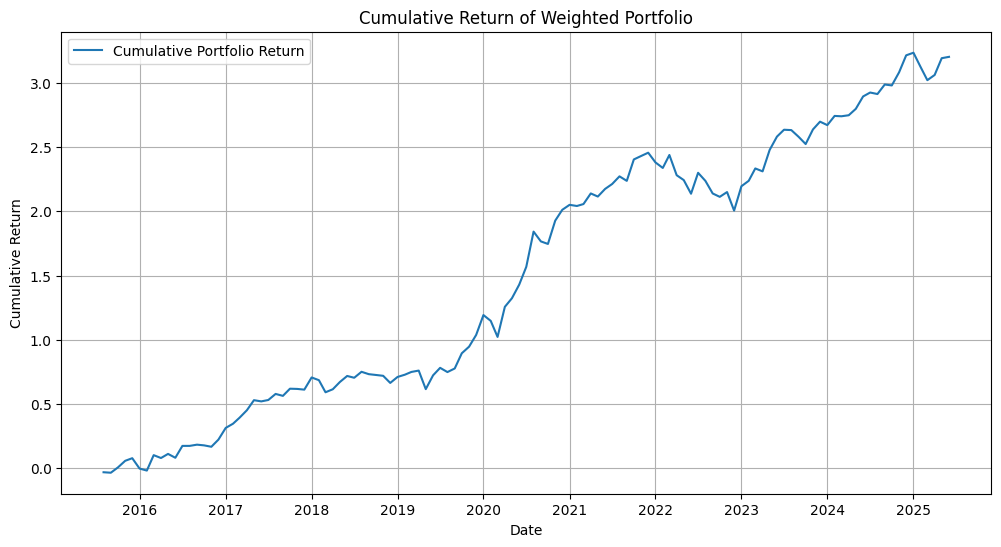

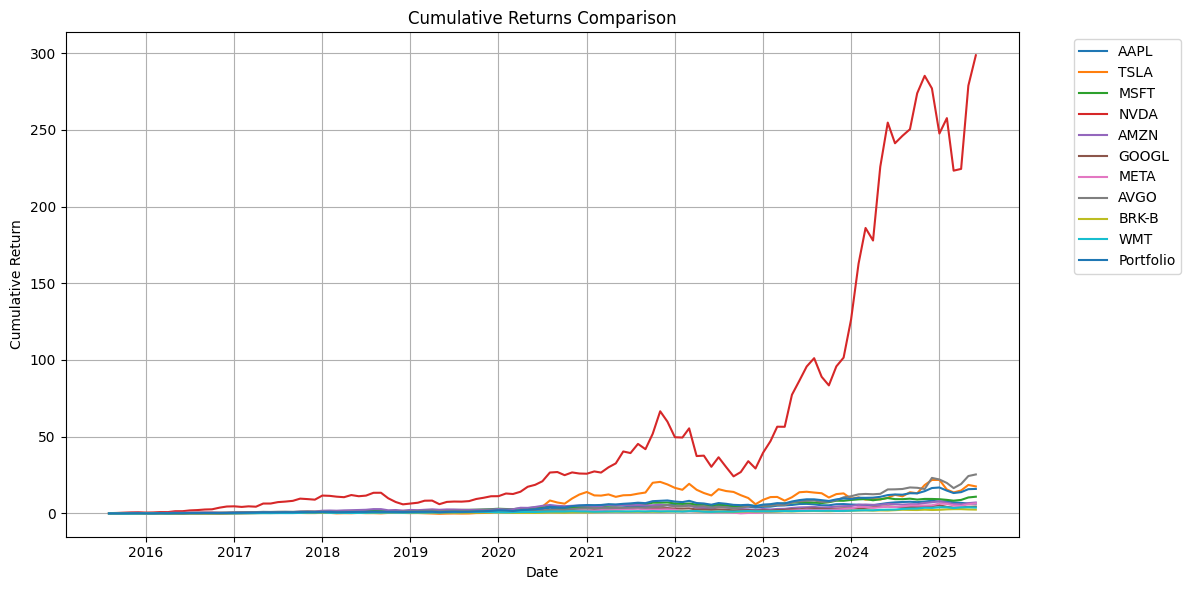


Portfolio Composition:
  Ticker    Weight
1   TSLA  0.234892
5  GOOGL  0.234735
7   AVGO  0.137462
0   AAPL  0.119081
8  BRK-B  0.077624
6   META  0.066920
4   AMZN  0.053918
3   NVDA  0.046377
2   MSFT  0.025214
9    WMT  0.003777


In [5]:
# Creiamo un DataFrame con i pesi per renderlo più facile da utilizzare
portfolio_df = pd.DataFrame({
    'Ticker': portfolio,
    'Weight': weights
})

# Calcoliamo il rendimento del portafoglio pesato
weighted_returns = pd.DataFrame()

# Per ogni data nel DataFrame dei rendimenti
for date in returns_df.index:
    # Moltiplichiamo i rendimenti di ogni titolo per il suo peso
    weighted_return = sum(returns_df.loc[date] * weights)
    weighted_returns.loc[date, 'Portfolio Return'] = weighted_return

# Stampiamo le statistiche del portafoglio pesato
portfolio_stats = pd.DataFrame({
    'Expected Return': weighted_returns['Portfolio Return'].mean(),
    'Variance': weighted_returns['Portfolio Return'].var(),
    'Standard Deviation': weighted_returns['Portfolio Return'].std()
}, index=['Weighted Portfolio'])

print("\nWeighted Portfolio Statistics:")
print(portfolio_stats.round(4))

# Visualizziamo l'andamento del portafoglio nel tempo
plt.figure(figsize=(12, 6))
plt.plot(weighted_returns.cumsum(), label='Cumulative Portfolio Return')
plt.title('Cumulative Return of Weighted Portfolio')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Confrontiamo le performance dei singoli titoli con il portafoglio
cumulative_returns = pd.DataFrame()

# Calcola i rendimenti cumulativi per ogni titolo
for ticker in portfolio:
    cumulative_returns[ticker] = (1 + returns_df[ticker]).cumprod() - 1

# Aggiungi il rendimento cumulativo del portafoglio
cumulative_returns['Portfolio'] = (1 + weighted_returns['Portfolio Return']).cumprod() - 1

# Plot dei rendimenti cumulativi
plt.figure(figsize=(12, 6))
for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column], label=column)
plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Stampa la composizione del portafoglio
print("\nPortfolio Composition:")
portfolio_composition = portfolio_df.sort_values(by='Weight', ascending=False)
print(portfolio_composition)